In [5]:
import math
import random

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(0)
random.seed(0)

# CPU setup
DEVICE = torch.device("cpu")

print("=" * 60)
print("LAB 7: TRANSFORMER ENCODER FROM SCRATCH")
print("=" * 60)

print("Python/PyTorch environment")
print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
print("CUDA available  :", torch.cuda.is_available())

LAB 7: TRANSFORMER ENCODER FROM SCRATCH
Python/PyTorch environment
PyTorch version : 2.13.0+cpu
Device          : cpu
CUDA available  : False


In [6]:
# ================================================================
# STEP 1: SCALED DOT-PRODUCT SELF-ATTENTION
# ================================================================

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: Query, Key and Value matrices

    Returns:
        output       : attention output
        attn_weights : attention weight matrix
    """
    
    # Dimension of each key/query vector
    d_k = Q.size(-1)

    # Calculate attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Apply mask if provided
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # Convert scores into probabilities
    attn_weights = torch.softmax(scores, dim=-1)

    # Weighted sum of Value vectors
    output = torch.matmul(attn_weights, V)

    return output, attn_weights


# ------------------------------------------------
# Create a small toy example
# ------------------------------------------------

batch = 1
seq_len = 4
d_k = 8

Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

# Apply self-attention
attention_output, attention_weights = scaled_dot_product_attention(Q, K, V)


# ------------------------------------------------
# Display results
# ------------------------------------------------

print("=" * 60)
print("STEP 1: SCALED DOT-PRODUCT SELF-ATTENTION")
print("=" * 60)

print("Input Q shape              :", Q.shape)
print("Input K shape              :", K.shape)
print("Input V shape              :", V.shape)
print("Output shape               :", attention_output.shape)
print("Attention weights shape    :", attention_weights.shape)

print("\nAttention Weight Matrix:")
print(attention_weights)

print("\nRow sums of attention weights:")
print(attention_weights.sum(dim=-1))

STEP 1: SCALED DOT-PRODUCT SELF-ATTENTION
Input Q shape              : torch.Size([1, 4, 8])
Input K shape              : torch.Size([1, 4, 8])
Input V shape              : torch.Size([1, 4, 8])
Output shape               : torch.Size([1, 4, 8])
Attention weights shape    : torch.Size([1, 4, 4])

Attention Weight Matrix:
tensor([[[0.1211, 0.7410, 0.1060, 0.0320],
         [0.2577, 0.2651, 0.1705, 0.3067],
         [0.3360, 0.0171, 0.1869, 0.4599],
         [0.2032, 0.6235, 0.1025, 0.0708]]])

Row sums of attention weights:
tensor([[1.0000, 1.0000, 1.0000, 1.0000]])


In [7]:
# ================================================================
# STEP 2: MULTI-HEAD ATTENTION FROM SCRATCH
# ================================================================

class MultiHeadAttentionScratch(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections for Query, Key and Value
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):

        # [batch, seq_len, d_model]
        # -> [batch, num_heads, seq_len, d_k]

        x = x.view(
            batch_size,
            -1,
            self.num_heads,
            self.d_k
        )

        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x, batch_size):

        # [batch, num_heads, seq_len, d_k]
        # -> [batch, seq_len, d_model]

        x = x.permute(0, 2, 1, 3).contiguous()

        return x.view(
            batch_size,
            -1,
            self.d_model
        )

    def forward(self, query, key, value, mask=None):

        batch_size = query.size(0)

        # Linear projections
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # Split into multiple heads
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # Scaled dot-product attention
        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        ) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(
                mask == 0,
                float("-inf")
            )

        attention_weights = torch.softmax(
            scores,
            dim=-1
        )

        attention_output = torch.matmul(
            attention_weights,
            V
        )

        # Combine all heads
        combined = self.combine_heads(
            attention_output,
            batch_size
        )

        # Final linear projection
        output = self.W_o(combined)

        return output, attention_weights


# ------------------------------------------------
# Create a toy input
# ------------------------------------------------

d_model = 32
num_heads = 4

toy_input = torch.randn(
    2,      # batch size
    6,      # sequence length
    d_model
)

mha = MultiHeadAttentionScratch(
    d_model=d_model,
    num_heads=num_heads
)

mha_output, mha_attention = mha(
    toy_input,
    toy_input,
    toy_input
)


# ------------------------------------------------
# Display results
# ------------------------------------------------

print("=" * 60)
print("STEP 2: MULTI-HEAD ATTENTION FROM SCRATCH")
print("=" * 60)

print("Input shape                  :", toy_input.shape)
print("Number of attention heads   :", num_heads)
print("Dimension per head          :", mha.d_k)
print("Output shape                :", mha_output.shape)
print("Attention weights shape     :", mha_attention.shape)

print("\nExpected attention shape:")
print("(batch, heads, seq_len, seq_len)")

print("\nAttention weights row sums:")
print(mha_attention.sum(dim=-1))



STEP 2: MULTI-HEAD ATTENTION FROM SCRATCH
Input shape                  : torch.Size([2, 6, 32])
Number of attention heads   : 4
Dimension per head          : 8
Output shape                : torch.Size([2, 6, 32])
Attention weights shape     : torch.Size([2, 4, 6, 6])

Expected attention shape:
(batch, heads, seq_len, seq_len)

Attention weights row sums:
tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]],
       grad_fn=<SumBackward1>)


STEP 3: SINUSOIDAL POSITIONAL ENCODING
Input embedding shape       : torch.Size([1, 50, 32])
Positional encoding shape   : torch.Size([1, 50, 32])

First 5 positions:
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.5332,  0.8460,  0.3110,  0.9504,  0.1769,  0.9842],
        [ 0.9093, -0.4161,  0.9021,  0.4315,  0.5911,  0.8066,  0.3482,  0.9374],
        [ 0.1411, -0.9900,  0.9933, -0.1160,  0.8126,  0.5828,  0.5085,  0.8610],
        [-0.7568, -0.6536,  0.7785, -0.6277,  0.9536,  0.3011,  0.6528,  0.7575]])


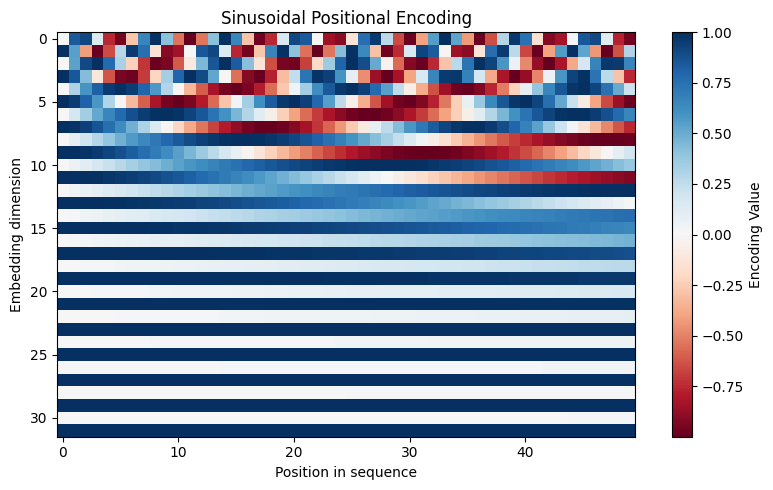


Heatmap saved as: positional_encoding_heatmap.png


In [8]:
# ================================================================
# STEP 3: SINUSOIDAL POSITIONAL ENCODING
# ================================================================

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=100):
        super().__init__()

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # Position indices
        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        # Frequency term
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        # Apply sine to even dimensions
        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        # Apply cosine to odd dimensions
        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        # Add batch dimension
        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self, x):

        seq_len = x.size(1)

        return x + self.pe[:, :seq_len, :]


# ------------------------------------------------
# Create positional encoding
# ------------------------------------------------

d_model = 32
max_len = 50

pos_encoding = PositionalEncoding(
    d_model=d_model,
    max_len=max_len
)

# Zero input embeddings
sample_embeddings = torch.zeros(
    1,
    max_len,
    d_model
)

# Add positional information
position_encoded = pos_encoding(
    sample_embeddings
)


# ------------------------------------------------
# Display result
# ------------------------------------------------

print("=" * 60)
print("STEP 3: SINUSOIDAL POSITIONAL ENCODING")
print("=" * 60)

print("Input embedding shape       :", sample_embeddings.shape)
print("Positional encoding shape   :", position_encoded.shape)

print("\nFirst 5 positions:")
print(position_encoded[0, :5, :8])


# ------------------------------------------------
# Visualize positional encoding
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.imshow(
    position_encoded[0].detach().numpy().T,
    cmap="RdBu",
    aspect="auto"
)

plt.colorbar(label="Encoding Value")

plt.xlabel("Position in sequence")
plt.ylabel("Embedding dimension")

plt.title("Sinusoidal Positional Encoding")

plt.tight_layout()

plt.savefig(
    "positional_encoding_heatmap.png",
    dpi=150
)

plt.show()

print("\nHeatmap saved as: positional_encoding_heatmap.png")

In [9]:
# ================================================================
# STEP 4: LAYER NORMALIZATION + RESIDUAL CONNECTION
# ================================================================

print("=" * 60)
print("STEP 4: LAYER NORMALIZATION + RESIDUAL CONNECTION")
print("=" * 60)

# Layer normalization
layer_norm = nn.LayerNorm(d_model)

# Original input = residual/skip connection
residual_input = toy_input

# Multi-head attention output from Step 2
sublayer_output = mha_output

# Residual connection followed by Layer Normalization
add_norm_output = layer_norm(
    residual_input + sublayer_output
)

# ------------------------------------------------
# Display results
# ------------------------------------------------

print("Residual input shape       :", residual_input.shape)
print("Attention output shape     :", sublayer_output.shape)
print("Add & Norm output shape    :", add_norm_output.shape)

# Mean and standard deviation across embedding dimensions
mean_values = add_norm_output.mean(dim=-1)
std_values = add_norm_output.std(dim=-1)

print("\nMean after LayerNorm (first 3 positions):")
print(mean_values[0, :3])

print("\nStd after LayerNorm (first 3 positions):")
print(std_values[0, :3])

STEP 4: LAYER NORMALIZATION + RESIDUAL CONNECTION
Residual input shape       : torch.Size([2, 6, 32])
Attention output shape     : torch.Size([2, 6, 32])
Add & Norm output shape    : torch.Size([2, 6, 32])

Mean after LayerNorm (first 3 positions):
tensor([1.4901e-08, 1.8626e-09, 3.9116e-08], grad_fn=<SliceBackward0>)

Std after LayerNorm (first 3 positions):
tensor([1.0160, 1.0160, 1.0160], grad_fn=<SliceBackward0>)


In [10]:
# ================================================================
# STEP 5: COMPLETE TRANSFORMER ENCODER BLOCK
# ================================================================

print("=" * 60)
print("STEP 5: COMPLETE TRANSFORMER ENCODER BLOCK")
print("=" * 60)


# ------------------------------------------------
# Feed-Forward Network
# ------------------------------------------------

class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x


# ------------------------------------------------
# Transformer Encoder Block
# ------------------------------------------------

class TransformerEncoderBlock(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        # Multi-Head Self-Attention
        self.mha = MultiHeadAttentionScratch(
            d_model,
            num_heads
        )

        # First Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)

        # Feed-Forward Network
        self.ff = FeedForward(
            d_model,
            d_ff
        )

        # Second Layer Normalization
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):

        # ----------------------------------------
        # Multi-Head Attention
        # ----------------------------------------

        attention_output, attention_weights = self.mha(
            x, x, x, mask
        )

        # ----------------------------------------
        # Residual Connection + LayerNorm
        # ----------------------------------------

        x = self.norm1(
            x + self.dropout(attention_output)
        )

        # ----------------------------------------
        # Feed-Forward Network
        # ----------------------------------------

        ff_output = self.ff(x)

        # ----------------------------------------
        # Second Residual Connection + LayerNorm
        # ----------------------------------------

        x = self.norm2(
            x + self.dropout(ff_output)
        )

        return x, attention_weights


# ------------------------------------------------
# Create Encoder Block
# ------------------------------------------------

d_model = 32
num_heads = 4
d_ff = 64

encoder_block = TransformerEncoderBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    dropout=0.1
)


# ------------------------------------------------
# Run the Encoder Block
# ------------------------------------------------

block_output, block_attention = encoder_block(
    toy_input
)


# ------------------------------------------------
# Display results
# ------------------------------------------------

print("Encoder block input shape  :", toy_input.shape)
print("Encoder block output shape :", block_output.shape)

print("\nAttention weights shape     :", block_attention.shape)

print("\nTransformer Encoder Block:")
print(encoder_block)

STEP 5: COMPLETE TRANSFORMER ENCODER BLOCK
Encoder block input shape  : torch.Size([2, 6, 32])
Encoder block output shape : torch.Size([2, 6, 32])

Attention weights shape     : torch.Size([2, 4, 6, 6])

Transformer Encoder Block:
TransformerEncoderBlock(
  (mha): MultiHeadAttentionScratch(
    (W_q): Linear(in_features=32, out_features=32, bias=True)
    (W_k): Linear(in_features=32, out_features=32, bias=True)
    (W_v): Linear(in_features=32, out_features=32, bias=True)
    (W_o): Linear(in_features=32, out_features=32, bias=True)
  )
  (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (ff): FeedForward(
    (linear1): Linear(in_features=32, out_features=64, bias=True)
    (linear2): Linear(in_features=64, out_features=32, bias=True)
    (relu): ReLU()
  )
  (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [11]:
# ================================================================
# STEP 6: VALIDATION AGAINST PYTORCH nn.MultiheadAttention
# ================================================================

print("=" * 60)
print("STEP 6: VALIDATION AGAINST nn.MultiheadAttention")
print("=" * 60)


# ------------------------------------------------
# Create PyTorch built-in MultiheadAttention
# ------------------------------------------------

torch_mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=num_heads,
    batch_first=True
)


# ------------------------------------------------
# Copy weights from our scratch implementation
# ------------------------------------------------

with torch.no_grad():

    # PyTorch stores Q, K and V weights together
    combined_weight = torch.cat(
        [
            mha.W_q.weight,
            mha.W_k.weight,
            mha.W_v.weight
        ],
        dim=0
    )

    combined_bias = torch.cat(
        [
            mha.W_q.bias,
            mha.W_k.bias,
            mha.W_v.bias
        ],
        dim=0
    )

    torch_mha.in_proj_weight.copy_(
        combined_weight
    )

    torch_mha.in_proj_bias.copy_(
        combined_bias
    )

    # Copy output projection
    torch_mha.out_proj.weight.copy_(
        mha.W_o.weight
    )

    torch_mha.out_proj.bias.copy_(
        mha.W_o.bias
    )


# ------------------------------------------------
# Generate outputs using both implementations
# ------------------------------------------------

scratch_output, scratch_attention = mha(
    toy_input,
    toy_input,
    toy_input
)

torch_output, torch_attention = torch_mha(
    toy_input,
    toy_input,
    toy_input
)


# ------------------------------------------------
# Calculate numerical difference
# ------------------------------------------------

max_abs_diff = (
    scratch_output - torch_output
).abs().max().item()


mean_abs_diff = (
    scratch_output - torch_output
).abs().mean().item()


# ------------------------------------------------
# Display validation results
# ------------------------------------------------

print("Scratch MHA output shape :", scratch_output.shape)
print("PyTorch MHA output shape :", torch_output.shape)

print("\nMaximum absolute difference :", f"{max_abs_diff:.8f}")
print("Mean absolute difference    :", f"{mean_abs_diff:.8f}")

print("\nValidation criterion:")
print("Maximum absolute difference should be very close to 0.")

if max_abs_diff < 1e-5:
    print("\nRESULT: PASS - Scratch implementation matches PyTorch.")
else:
    print("\nRESULT: CHECK - Difference is larger than expected.")

STEP 6: VALIDATION AGAINST nn.MultiheadAttention
Scratch MHA output shape : torch.Size([2, 6, 32])
PyTorch MHA output shape : torch.Size([2, 6, 32])

Maximum absolute difference : 0.00000009
Mean absolute difference    : 0.00000001

Validation criterion:
Maximum absolute difference should be very close to 0.

RESULT: PASS - Scratch implementation matches PyTorch.


STEP 7: TRAINING ON A TOY COPY TASK
Epoch [ 20/100]  Loss: 1.5023  Token Accuracy: 70.31%
Epoch [ 40/100]  Loss: 0.7390  Token Accuracy: 99.74%
Epoch [ 60/100]  Loss: 0.3633  Token Accuracy: 100.00%
Epoch [ 80/100]  Loss: 0.1995  Token Accuracy: 100.00%
Epoch [100/100]  Loss: 0.1296  Token Accuracy: 100.00%


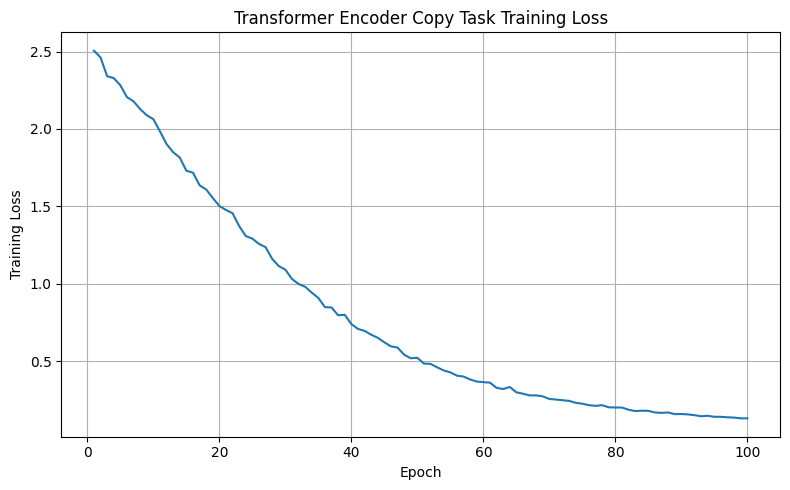


Final Test Result
----------------------------------------
Final test token accuracy : 100.00%
RESULT: PASS - High copy-task accuracy achieved.


In [12]:
# ================================================================
# STEP 7: TRAINING ON A TOY COPY TASK
# ================================================================

print("=" * 60)
print("STEP 7: TRAINING ON A TOY COPY TASK")
print("=" * 60)


# ------------------------------------------------
# Copy Task Model
# ------------------------------------------------

VOCAB_SIZE = 12
SEQ_LEN = 6
D_MODEL = 32


class CopyTaskModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        max_len
    ):
        super().__init__()

        # Token embedding
        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        # Positional encoding
        self.pos_encoding = PositionalEncoding(
            d_model,
            max_len=max_len
        )

        # Transformer Encoder Block
        self.encoder_block = TransformerEncoderBlock(
            d_model,
            num_heads,
            d_ff
        )

        # Output classification layer
        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, x):

        # Convert token IDs to embeddings
        embedded = self.embedding(x)

        # Add positional information
        embedded = self.pos_encoding(embedded)

        # Pass through Transformer Encoder
        encoded, attention_weights = self.encoder_block(
            embedded
        )

        # Predict token at each position
        logits = self.output_layer(encoded)

        return logits, attention_weights


# ------------------------------------------------
# Generate copy-task training data
# ------------------------------------------------

def make_copy_batch(
    batch_size,
    seq_len,
    vocab_size
):

    # Generate random tokens from 1 to vocab_size-1
    x = torch.randint(
        1,
        vocab_size,
        (batch_size, seq_len)
    )

    # Target is exactly the same sequence
    y = x.clone()

    return x, y


# ------------------------------------------------
# Create model
# ------------------------------------------------

copy_model = CopyTaskModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=4,
    d_ff=64,
    max_len=SEQ_LEN
).to(DEVICE)


# ------------------------------------------------
# Loss function and optimizer
# ------------------------------------------------

optimizer = optim.Adam(
    copy_model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------
# Training
# ------------------------------------------------

EPOCHS = 100

loss_history = []

for epoch in range(EPOCHS):

    # Generate a fresh random batch
    x_batch, y_batch = make_copy_batch(
        batch_size=64,
        seq_len=SEQ_LEN,
        vocab_size=VOCAB_SIZE
    )

    x_batch = x_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    logits, _ = copy_model(x_batch)

    # Calculate loss
    loss = criterion(
        logits.reshape(-1, VOCAB_SIZE),
        y_batch.reshape(-1)
    )

    # Backpropagation
    loss.backward()

    # Update model parameters
    optimizer.step()

    loss_history.append(loss.item())

    # Display progress
    if (epoch + 1) % 20 == 0:

        predictions = logits.argmax(dim=-1)

        accuracy = (
            predictions == y_batch
        ).float().mean().item()

        print(
            f"Epoch [{epoch + 1:3d}/{EPOCHS}]  "
            f"Loss: {loss.item():.4f}  "
            f"Token Accuracy: {accuracy:.2%}"
        )


# ------------------------------------------------
# Plot training loss
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Encoder Copy Task Training Loss")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "copy_task_training_loss.png",
    dpi=150
)

plt.show()


# ------------------------------------------------
# Final evaluation
# ------------------------------------------------

test_x, test_y = make_copy_batch(
    batch_size=200,
    seq_len=SEQ_LEN,
    vocab_size=VOCAB_SIZE
)

test_x = test_x.to(DEVICE)
test_y = test_y.to(DEVICE)

with torch.no_grad():

    test_logits, _ = copy_model(test_x)

    test_predictions = test_logits.argmax(
        dim=-1
    )

    test_accuracy = (
        test_predictions == test_y
    ).float().mean().item()


print("\nFinal Test Result")
print("-" * 40)
print(
    f"Final test token accuracy : "
    f"{test_accuracy:.2%}"
)

if test_accuracy >= 0.90:
    print(
        "RESULT: PASS - High copy-task accuracy achieved."
    )
else:
    print(
        "RESULT: Model has not yet reached 90% accuracy."
    )

In [ ]:
## STEP 8: IN-LAB OBSERVATIONS AND CONCLUSION

### Observations

1. Scaled Dot-Product Self-Attention calculated attention between all positions in the input sequence. The attention weight rows summed to 1.0, confirming that the softmax normalization was working correctly.

2. Multi-Head Attention divided the 32-dimensional representation into 4 heads, with 8 dimensions per head. The output shape was preserved as (2, 6, 32).

3. Sinusoidal Positional Encoding added positional information to the input embeddings. The heatmap showed a periodic pattern, with different embedding dimensions having different wavelengths.

4. Layer Normalization with the residual connection produced an output with mean approximately equal to zero and standard deviation close to one.

5. The complete Transformer Encoder block consisted of Multi-Head Attention, Add & Norm, Feed-Forward Network, and another Add & Norm operation.

6. The from-scratch Multi-Head Attention implementation was validated against PyTorch's `nn.MultiheadAttention`. The maximum absolute difference was 0.00000009, which is very close to zero and confirms numerical correctness.

7. The encoder was trained on a toy copy task. Training loss decreased from about 2.5 to 0.13, and the final test token accuracy reached 100.00%.

### Conclusion

The Transformer Encoder block was successfully implemented from scratch using PyTorch. The attention mechanism, multi-head attention, positional encoding, residual connections, and layer normalization worked as expected. The numerical validation and 100% copy-task accuracy confirm that the implementation is functioning correctly.